<a href="https://colab.research.google.com/github/cjsdudwls1/-2026_Spring_Data_Standardization/blob/main/1%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3가지 대표 통계적 샘플링 법:seaborn의 tips dataset

In [ ]:
import seaborn as sns
import pandas as pd

# seaborn의 내장 tips 데이터셋 로드
df = sns.load_dataset('tips')

# 데이터프레임 정보 확인
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 1. 단순 무작위 추출 (Simple Random Sampling)

In [ ]:
simple_sample = df.sample(n=30, random_state=42)
print("--- 단순 무작위 추출 (n=30) ---")
display(simple_sample)

--- 단순 무작위 추출 (n=30) ---


,total_bill,tip,sex,smoker,day,time,size
24,19.82,3.18,Male,No,Sat,Dinner,2
6,8.77,2.00,Male,No,Sun,Dinner,2
153,24.55,2.00,Male,No,Sun,Dinner,4
211,25.89,5.16,Male,Yes,Sat,Dinner,4
198,13.00,2.00,Female,Yes,Thur,Lunch,2
176,17.89,2.00,Male,Yes,Sun,Dinner,2
192,28.44,2.56,Male,Yes,Thur,Lunch,2
124,12.48,2.52,Female,No,Thur,Lunch,2
9,14.78,3.23,Male,No,Sun,Dinner,2
101,15.38,3.00,Female,Yes,Fri,Dinner,2


# 2. 층화 무작위 추출 (Stratified Sampling)

In [ ]:
# 'sex' 컬럼을 기준으로 층화 추출을 수행합니다.
stratified_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(n=1, random_state=42))
# 3개를 맞추기 위해 추가 샘플링하거나 비율을 조정할 수 있으나, 개념 설명을 위해 각 성별 층에서 샘플링 후 총 30개를 선택합니다.
stratified_sample_final = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(frac=0.02, random_state=42)).head(30)

print("--- 층화 무작위 추출 (sex 기준) ---")
display(stratified_sample_final)

--- 층화 무작위 추출 (sex 기준) ---


/tmp/ipykernel_307/1335217331.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(n=1, random_state=42))
/tmp/ipykernel_307/1335217331.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(n=1, random_state=42))
/tmp/ipykernel_307/1335217331.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

,total_bill,tip,sex,smoker,day,time,size
194,16.58,4.00,Male,Yes,Thur,Lunch,2
60,20.29,3.21,Male,Yes,Sat,Dinner,2
207,38.73,3.00,Male,Yes,Sat,Dinner,4
214,28.17,6.50,Female,Yes,Sat,Dinner,3
0,16.99,1.01,Female,No,Sun,Dinner,2


## 2-1 균등층화

In [ ]:
# 각 층(sex)에서 동일한 개수(n=2)를 무작위로 추출하는 균등층화 방식
equal_stratified_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(n=15, random_state=42))

print("--- 균등층화 추출 (성별 각 15개씩) ---")
display(equal_stratified_sample)
print("\n각 성별 샘플 수:")
print(equal_stratified_sample['sex'].value_counts())

--- 균등층화 추출 (성별 각 15개씩) ---


/tmp/ipykernel_307/1316567698.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  equal_stratified_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(n=15, random_state=42))
/tmp/ipykernel_307/1316567698.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  equal_stratified_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(n=15, random_state=42))


,total_bill,tip,sex,smoker,day,time,size
194,16.58,4.00,Male,Yes,Thur,Lunch,2
60,20.29,3.21,Male,Yes,Sat,Dinner,2
207,38.73,3.00,Male,Yes,Sat,Dinner,4
216,28.15,3.00,Male,Yes,Sat,Dinner,5
175,32.90,3.11,Male,Yes,Sun,Dinner,2
41,17.46,2.54,Male,No,Sun,Dinner,2
152,17.26,2.74,Male,No,Sun,Dinner,3
154,19.77,2.00,Male,No,Sun,Dinner,4
151,13.13,2.00,Male,No,Sun,Dinner,2
217,11.59,1.50,Male,Yes,Sat,Dinner,2



각 성별 샘플 수:
sex
Male      15
Female    15
Name: count, dtype: int64


## 2-2 비례층화

In [ ]:
# 2-2 비례층화 (Proportional Stratified Sampling)
# 전체 데이터의 10%를 각 성별(sex) 비율에 맞춰 추출합니다.
proportional_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

print("--- 비례층화 추출 (전체 대비 10%) ---")
display(proportional_sample)

print("\n--- 원본 데이터 성별 비율 ---")
print(df['sex'].value_counts(normalize=True))

print("\n--- 샘플 데이터 성별 비율 ---")
print(proportional_sample['sex'].value_counts(normalize=True))

--- 비례층화 추출 (전체 대비 10%) ---


/tmp/ipykernel_307/3962732140.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportional_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))
/tmp/ipykernel_307/3962732140.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  proportional_sample = df.groupby('sex', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


,total_bill,tip,sex,smoker,day,time,size
194,16.58,4.00,Male,Yes,Thur,Lunch,2
60,20.29,3.21,Male,Yes,Sat,Dinner,2
207,38.73,3.00,Male,Yes,Sat,Dinner,4
216,28.15,3.00,Male,Yes,Sat,Dinner,5
175,32.90,3.11,Male,Yes,Sun,Dinner,2
41,17.46,2.54,Male,No,Sun,Dinner,2
152,17.26,2.74,Male,No,Sun,Dinner,3
154,19.77,2.00,Male,No,Sun,Dinner,4
151,13.13,2.00,Male,No,Sun,Dinner,2
217,11.59,1.50,Male,Yes,Sat,Dinner,2



--- 원본 데이터 성별 비율 ---
sex
Male      0.643443
Female    0.356557
Name: proportion, dtype: float64

--- 샘플 데이터 성별 비율 ---
sex
Male      0.64
Female    0.36
Name: proportion, dtype: float64


# 3. 집락 추출 (Cluster Sampling)

In [ ]:
import random

# 'day'를 집락(Cluster)으로 설정합니다.
clusters = df['day'].unique().tolist()
# 무작위로 1개의 집락(요일)을 선택
selected_cluster = random.choice(clusters)

# 선택된 집락 내에서 3개 샘플링
cluster_sample = df[df['day'] == selected_cluster].sample(n=30, random_state=42)

print(f"--- 집락 추출 (선택된 집락: {selected_cluster}) ---")
display(cluster_sample)

--- 집락 추출 (선택된 집락: Thur) ---


,total_bill,tip,sex,smoker,day,time,size
195,7.56,1.44,Male,No,Thur,Lunch,2
201,12.74,2.01,Female,Yes,Thur,Lunch,2
77,27.20,4.00,Male,No,Thur,Lunch,4
202,13.00,2.00,Female,Yes,Thur,Lunch,2
82,10.07,1.83,Female,No,Thur,Lunch,1
193,15.48,2.02,Male,Yes,Thur,Lunch,2
120,11.69,2.31,Male,No,Thur,Lunch,2
89,21.16,3.00,Male,No,Thur,Lunch,2
129,22.82,2.18,Male,No,Thur,Lunch,3
204,20.53,4.00,Male,Yes,Thur,Lunch,4


1. 단순 무작위 추출
모집단에서 뽑고 싶은 만큼 무작위 추출

2. 층화 무작위 추출 <br>
2.1 비례 층화 추출: <br>선택한 층화에서 비율로써 집단 별 무작위 추출(예: 경기도100명, 부산 200명이라면 각 10%인 10, 20명씩 추출)<br>
2.2 균등 층화 추출: <br>그냥 고정 값 추출

3. 집락 무작위 추출: 선택한 칼럼의 유니크 값 하나만 뽑아서 그 전체를 하나의 표본으로 취급. 여러개 뽑으면 그 모두가 하나의 샘플

# seaborn의 tip 변수의 값(데이터) 분포, 평균, 분산을 설명하라

[tip 변수 통계 정보]
평균 (Mean): 3.00
분산 (Variance): 1.91


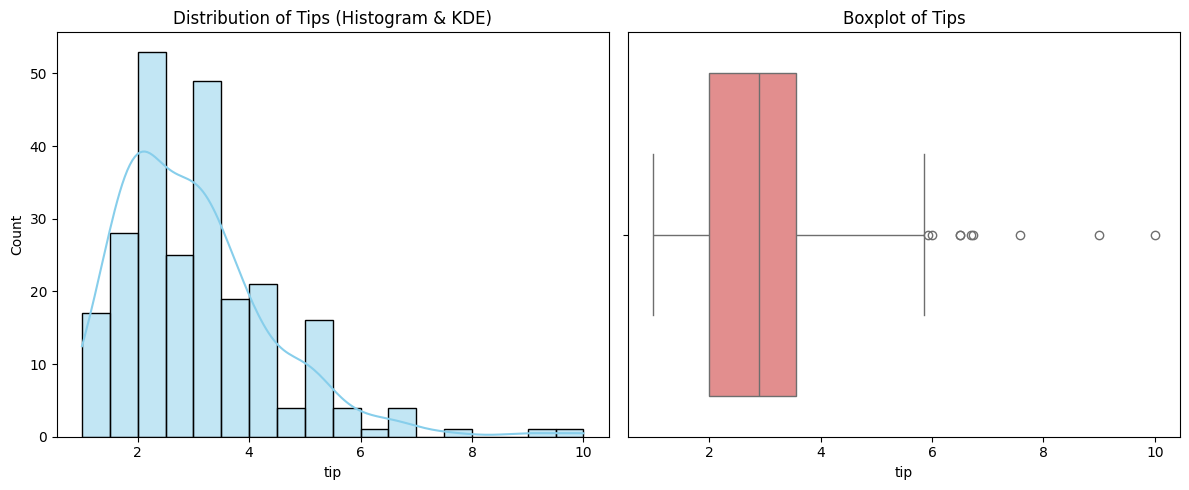

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. 기초 통계량 계산
tip_mean = df['tip'].mean()
tip_var = df['tip'].var()

print(f"[tip 변수 통계 정보]")
print(f"평균 (Mean): {tip_mean:.2f}")
print(f"분산 (Variance): {tip_var:.2f}")

# 2. 데이터 분포 시각화 (그래프가 잘 보이도록 설정)
plt.figure(figsize=(12, 5))

# 히스토그램 & KDE (전체적인 분포 형태)
plt.subplot(1, 2, 1)
sns.histplot(df['tip'], kde=True, color='skyblue')
plt.title('Distribution of Tips (Histogram & KDE)')

# 박스플롯 (사분위수 및 이상치 확인)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['tip'], color='lightcoral')
plt.title('Boxplot of Tips')

plt.tight_layout()
plt.show()

#seaborn의 tips 모집단에서 3가지 표본추출방법의 각 표본과 모집단과의 평균과 분산을 비교한 후 어떤 표본 추출 방법이 가장 적합한지 토론하라

## 1단계:
- 모집단의 진짜 평균과 분산(모수) 구하기먼저, <br>
- 비교의 기준이 될 전체 tips 데이터에서 팁(tip) 금액의 진짜 평균($\mu$)과 분산($\sigma^2$)을 알아야 합니다.<br>
- Pandas 데이터프레임에서는 .mean()과 .var() 메서드를 통해 특정 칼럼의 통계량을 쉽게 계산할 수 있습니다.

In [ ]:
import seaborn as sns
import pandas as pd

# 데이터 불러오기
tips = sns.load_dataset('tips')

# 모집단(전체 데이터)의 팁 평균과 분산 계산
pop_mean = tips['tip'].mean()
pop_var = tips['tip'].var()

print(f"모집단 팁 평균: {pop_mean:.3f}")
print(f"모집단 팁 분산: {pop_var:.3f}")

모집단 팁 평균: 2.998
모집단 팁 분산: 1.914


## 2단계: 3가지 방법으로 표본 추출하기 (n=50)

In [ ]:
# 2. 단순 무작위 추출 (n=50)
# 전체 데이터에서 아무 조건 없이 50개 추출
srs = tips.sample(n=50, random_state=42)
print(f"🎲 [단순 무작위] 평균: {srs['tip'].mean():.3f}, 분산: {srs['tip'].var():.3f}")

# 3. 비례 층화 추출 (n=50)
# 요일('day')별 데이터 비율에 맞춰서 총 50개 추출
props = tips['day'].value_counts(normalize=True)
strata_sizes = (props * 50).round().astype(int)

# (참고) 반올림 때문에 총합이 50개가 안 될 경우, 가장 큰 그룹에서 개수 조정
if strata_sizes.sum() != 50:
    strata_sizes.iloc[0] += (50 - strata_sizes.sum())

stratified = pd.concat([
    tips[tips['day'] == day].sample(n=size, random_state=42)
    for day, size in strata_sizes.items()
])
print(f"🍰 [비례 층화] 평균: {stratified['tip'].mean():.3f}, 분산: {stratified['tip'].var():.3f}")

# 4. 집락 추출 (n=50)
# 요일이라는 군집 중 하나(예: 일요일)를 통째로 선택한 상황 가정
# (원래 집락 전체를 다 봐야 하지만, n=50 비교를 위해 일요일 데이터 중 50개만 확인)
cluster = tips[tips['day'] == 'Sun'].sample(n=50, random_state=42)
print(f"🏘️ [집락 추출(일요일)] 평균: {cluster['tip'].mean():.3f}, 분산: {cluster['tip'].var():.3f}")

🎲 [단순 무작위] 평균: 2.644, 분산: 1.250
🍰 [비례 층화] 평균: 2.988, 분산: 1.802
🏘️ [집락 추출(일요일)] 평균: 3.205, 분산: 1.447


## 비레층화추출이 당연하게 가장 높은 설명력. 근데 팁이랑 관계없는 층을 고르면?

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Seaborn의 원본 tips 데이터 불러오기
tips = sns.load_dataset('tips')

# 모집단(전체 244개 데이터)의 진짜 평균과 분산
pop_mean = tips['tip'].mean()
pop_var = tips['tip'].var()

# --- 표본 추출 (n=50) ---

# 1. 단순 무작위 추출
srs_sample = tips.sample(n=50, random_state=42)

# 2. 비례 층화 추출 (기준: 'sex')
props = tips['sex'].value_counts(normalize=True)
strata_sizes = (props * 50).round().astype(int)

# 반올림 오차 보정 (총합이 정확히 50이 되도록)
if strata_sizes.sum() != 50:
    strata_sizes.iloc[0] += (50 - strata_sizes.sum())

strat_sample = pd.concat([
    tips[tips['sex'] == sex].sample(n=size, random_state=42)
    for sex, size in strata_sizes.items()
])

# 3. 집락 추출 (비교를 위해 'Female' 그룹만 통째로 선택했다고 가정)
cluster_sample = tips[tips['sex'] == 'Female'].sample(n=50, random_state=42)

# --- 결과 비교 표 만들기 ---
results = pd.DataFrame({
    '추출 방법': ['모집단(전체)', '단순무작위', '비례층화(sex 기준)', '집락(여성만)'],
    '평균': [pop_mean, srs_sample['tip'].mean(), strat_sample['tip'].mean(), cluster_sample['tip'].mean()],
    '분산': [pop_var, srs_sample['tip'].var(), strat_sample['tip'].var(), cluster_sample['tip'].var()]
})

# 모평균과의 차이(오차) 계산
results['오차(절대값)'] = abs(results['평균'] - pop_mean)
results.loc[0, '오차(절대값)'] = 0.0

print(results.round(3))

          추출 방법     평균     분산  오차(절대값)
0       모집단(전체)  2.998  1.914    0.000
1         단순무작위  2.644  1.250    0.355
2  비례층화(sex 기준)  3.292  1.935    0.294
3       집락(여성만)  3.054  1.446    0.056


## 우연적으로 집락이 1등이 나옴. 여러번 하면 다르게 나올것이라 함.

# https://github.com/ancestor9/data/blob/main/customers.csv 의 데이터를 데이터셋으로 읽은 후 컴퓨터가 인식할 수 있도록 모든 데이터를 수치화하여 표현하라

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. GitHub의 Raw 데이터 주소 (기존 주소에서 raw.githubusercontent.com 형식으로 변경됨)
url = "https://raw.githubusercontent.com/ancestor9/data/main/customers.csv"

# 2. 데이터셋 읽어오기
df = pd.read_csv(url)

print("👀 [변환 전] 원본 데이터 미리보기:")
print(df.head(), "\n")

👀 [변환 전] 원본 데이터 미리보기:
        고객ID  성별   결제수단 거주지  회원등급  만족도  최근접속시간(시)  선호제품군_적정온도  나이  구매수량  \
0  CUST_0001  남성  휴대폰결제  대구  Gold    2          1        27.0  34     7   
1  CUST_0002  여성   계좌이체  대구  Gold    5         15        24.6  20    42   
2  CUST_0003  여성   신용카드  광주  Gold    1          6        20.3  51     8   
3  CUST_0004  여성   계좌이체  서울  VVIP    5         20        16.8  19    29   
4  CUST_0005  여성   계좌이체  광주  Gold    3          6        23.5  53    45   

    총결제금액  
0  760355  
1  727001  
2  618787  
3  434545  
4  604750   



In [ ]:
df

,고객ID,성별,결제수단,거주지,회원등급,만족도,최근접속시간(시),선호제품군_적정온도,나이,구매수량,총결제금액
0,CUST_0001,남성,휴대폰결제,대구,Gold,2,1,27.0,34,7,760355
1,CUST_0002,여성,계좌이체,대구,Gold,5,15,24.6,20,42,727001
2,CUST_0003,여성,신용카드,광주,Gold,1,6,20.3,51,8,618787
3,CUST_0004,여성,계좌이체,서울,VVIP,5,20,16.8,19,29,434545
4,CUST_0005,여성,계좌이체,광주,Gold,3,6,23.5,53,45,604750
...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST_9996,여성,간편결제,대구,Gold,3,14,21.2,59,3,934416
9996,CUST_9997,여성,휴대폰결제,경기,Silver,5,13,21.6,48,4,417516
9997,CUST_9998,여성,휴대폰결제,부산,VIP,3,23,25.9,59,31,163234
9998,CUST_9999,기타,휴대폰결제,서울,Gold,4,20,24.0,24,38,986091


In [ ]:
# 데이터 프레임 복사 (원본 보존용)
df_label = df.copy()
df_onehot = df.copy()

# 문자열(object) 형태인 칼럼만 자동으로 찾아내기
categorical_cols = df.select_dtypes(include=['object']).columns

# 방법 A: 라벨 인코딩 (Label Encoding)
# 'Male', 'Female'을 0, 1 같은 단순 정수로 변환합니다. (트리 기반 모델에 적합)
le = LabelEncoder()
for col in categorical_cols:
    df_label[col] = le.fit_transform(df_label[col])

print("🔢 [방법 A] 라벨 인코딩 결과:")
print(df_label.head(), "\n")

# 방법 B: 원-핫 인코딩 (One-Hot Encoding)
# 카테고리마다 새로운 칼럼을 만들어 0과 1로 표시합니다. (선형 회귀, 딥러닝 등에 적합)
df_onehot = pd.get_dummies(df_onehot, columns=categorical_cols, drop_first=True)

print("🔥 [방법 B] 원-핫 인코딩 결과:")
print(df_onehot.head())

🔢 [방법 A] 라벨 인코딩 결과:
   고객ID  성별  결제수단  거주지  회원등급  만족도  최근접속시간(시)  선호제품군_적정온도  나이  구매수량   총결제금액
0     0   1     3    2     1    2          1        27.0  34     7  760355
1     1   2     1    2     1    5         15        24.6  20    42  727001
2     2   2     2    1     1    1          6        20.3  51     8  618787
3     3   2     1    4     4    5         20        16.8  19    29  434545
4     4   2     1    1     1    3          6        23.5  53    45  604750 

🔥 [방법 B] 원-핫 인코딩 결과:
   만족도  최근접속시간(시)  선호제품군_적정온도  나이  구매수량   총결제금액  고객ID_CUST_0002  \
0    2          1        27.0  34     7  760355           False   
1    5         15        24.6  20    42  727001            True   
2    1          6        20.3  51     8  618787           False   
3    5         20        16.8  19    29  434545           False   
4    3          6        23.5  53    45  604750           False   

   고객ID_CUST_0003  고객ID_CUST_0004  고객ID_CUST_0005  ...  결제수단_신용카드  결제수단_휴대폰결제  \
0           False      

In [ ]:
df_label

,고객ID,성별,결제수단,거주지,회원등급,만족도,최근접속시간(시),선호제품군_적정온도,나이,구매수량,총결제금액
0,0,1,3,2,1,2,1,27.0,34,7,760355
1,1,2,1,2,1,5,15,24.6,20,42,727001
2,2,2,2,1,1,1,6,20.3,51,8,618787
3,3,2,1,4,4,5,20,16.8,19,29,434545
4,4,2,1,1,1,3,6,23.5,53,45,604750
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,2,0,2,1,3,14,21.2,59,3,934416
9996,9997,2,3,0,2,5,13,21.6,48,4,417516
9997,9998,2,3,3,3,3,23,25.9,59,31,163234
9998,9999,0,3,4,1,4,20,24.0,24,38,986091


In [ ]:
df_label.shape

(10000, 11)

In [ ]:
df_onehot

,만족도,최근접속시간(시),선호제품군_적정온도,나이,구매수량,총결제금액,고객ID_CUST_0002,고객ID_CUST_0003,고객ID_CUST_0004,고객ID_CUST_0005,...,결제수단_신용카드,결제수단_휴대폰결제,거주지_광주,거주지_대구,거주지_부산,거주지_서울,회원등급_Gold,회원등급_Silver,회원등급_VIP,회원등급_VVIP
0,2,1,27.0,34,7,760355,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
1,5,15,24.6,20,42,727001,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
2,1,6,20.3,51,8,618787,False,True,False,False,...,True,False,True,False,False,False,True,False,False,False
3,5,20,16.8,19,29,434545,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
4,3,6,23.5,53,45,604750,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,14,21.2,59,3,934416,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
9996,5,13,21.6,48,4,417516,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
9997,3,23,25.9,59,31,163234,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
9998,4,20,24.0,24,38,986091,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False


In [ ]:
df_onehot.shape

(10000, 10018)